1, Loading the model

In [5]:
import pandas as pd
import joblib
import os
import shap
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the model we saved in Task 2
model_path = os.path.join('..', 'models', 'random_forest_fraud_model.pkl')
best_rf = joblib.load(model_path)

# 2. Load the processed data
data_path = os.path.join('..', 'data', 'processed', 'processed_fraud_data.csv')
df = pd.read_csv(data_path)

# 3. Prepare the data (Same as Task 2)
X = df.drop(columns=['class', 'user_id', 'device_id', 'signup_time', 'purchase_time'])
y = df['class']

# Note: We use the full X here for feature importance, 
# but we will sample for SHAP to save time.
print("Model and data loaded successfully!")

Model and data loaded successfully!


2, Feature Importance Baseline

C:\Users\Home-User\AppData\Local\Temp\ipykernel_496\1170709672.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=fi_df.head(10), palette='viridis')


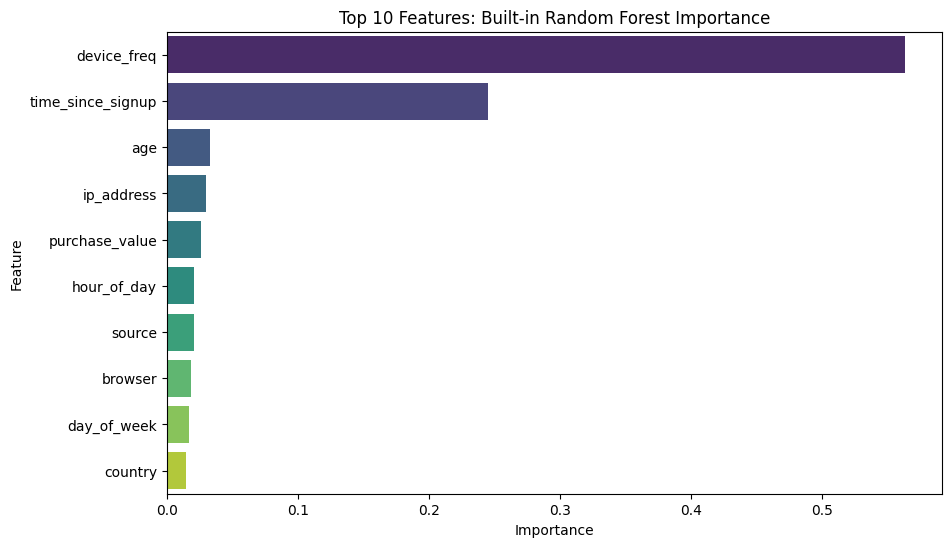

In [6]:
# Extract built-in importance
importances = best_rf.feature_importances_
feature_names = X.columns
fi_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
fi_df = fi_df.sort_values(by='Importance', ascending=False)

# Visualize Top 10
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=fi_df.head(10), palette='viridis')
plt.title('Top 10 Features: Built-in Random Forest Importance')
plt.show()

3, SHAP Global Summary

SHAP shape: (300, 12)
Feature matrix shape: (300, 12)


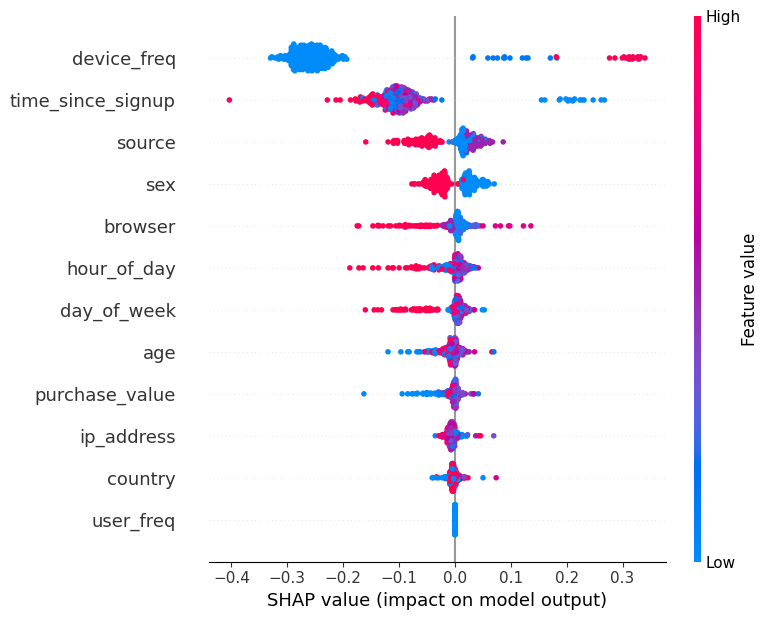

In [7]:
import numpy as np

# 1. Calculate SHAP values
# We use the TreeExplainer on our best model
X = df.drop(columns=['class', 'user_id', 'device_id', 'signup_time', 'purchase_time'])
X_sample = X.sample(300, random_state=42)
explainer = shap.TreeExplainer(best_rf)
shap_values = explainer.shap_values(X_sample)

# 2. Handle the Dimension Mismatch
# Random Forest in SHAP often returns a list [matrix_for_class_0, matrix_for_class_1]
# We only care about class 1 (Fraud)
if isinstance(shap_values, list):
    # If it's a list, take the second element (Fraud)
    shap_values_to_plot = shap_values[1]
elif len(shap_values.shape) == 3:
    # If it's a 3D array (samples, features, classes), slice for the last class
    shap_values_to_plot = shap_values[:, :, 1]
else:
    # If it's already 2D, use as is
    shap_values_to_plot = shap_values

# 3. Final Check: Ensure features match
print(f"SHAP shape: {shap_values_to_plot.shape}")
print(f"Feature matrix shape: {X_sample.shape}")

# 4. Generate Summary Plot
shap.summary_plot(shap_values_to_plot, X_sample)

4, Force Plots (Individual Predictions)

In [9]:
from sklearn.model_selection import train_test_split

# Recreate the split using the SAME random_state as Task 2
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

print(f"Test set recreated: {X_test.shape}")

Test set recreated: (30223, 12)


In [11]:
# 1. Generate predictions using your best model
y_pred = best_rf.predict(X_test)

# 2. Find indices for the three required report cases
# True Positive: Model said Fraud, actually was Fraud
tp_indices = X_test[(y_test == 1) & (y_pred == 1)].index
tp_idx = tp_indices[0] if len(tp_indices) > 0 else None

# False Positive: Model said Fraud, actually was Legitimate
fp_indices = X_test[(y_test == 0) & (y_pred == 1)].index
fp_idx = fp_indices[0] if len(fp_indices) > 0 else None

# False Negative: Model said Legitimate, actually was Fraud
fn_indices = X_test[(y_test == 1) & (y_pred == 0)].index
fn_idx = fn_indices[0] if len(fn_indices) > 0 else None

print(f"Indices found -> TP: {tp_idx}, FP: {fp_idx}, FN: {fn_idx}")

Indices found -> TP: 26528, FP: 29219, FN: 137399


In [12]:
import shap
import numpy as np
shap.initjs() 

def show_force_plot(idx, title):
    if idx is None:
        print(f"Skipping {title}: No cases found in dataset.")
        return
        
    print(f"\n--- {title} (Index: {idx}) ---")
    raw_shap = explainer.shap_values(X_test.loc[[idx]])
    
    # Handle list/matrix shape for Random Forest
    if isinstance(raw_shap, list):
        instance_shap = raw_shap[1]
    elif len(raw_shap.shape) == 3:
        instance_shap = raw_shap[:, :, 1]
    else:
        instance_shap = raw_shap
        
    instance_shap = np.array(instance_shap).flatten()
    
    display(shap.force_plot(
        explainer.expected_value[1], 
        instance_shap, 
        X_test.loc[[idx]]
    ))

# Generate the 3 required plots for Task 3
show_force_plot(tp_idx, "True Positive: Correctly Flagged Fraud")
show_force_plot(fp_idx, "False Positive: Legitimate Flagged as Fraud")
show_force_plot(fn_idx, "False Negative: Missed Fraudulent Transaction")


--- True Positive: Correctly Flagged Fraud (Index: 26528) ---



--- False Positive: Legitimate Flagged as Fraud (Index: 29219) ---



--- False Negative: Missed Fraudulent Transaction (Index: 137399) ---
